# PSP Model Visualizers

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import neurodsp simulations for synaptic activity
from neurodsp.sim.transients import sim_synaptic_kernel
from neurodsp.sim.aperiodic import sim_synaptic_current, sim_poisson_pop

# Import neurodsp plotting & utilities
from neurodsp.spectral.power import compute_spectrum, compute_spectrum_fft
from neurodsp.utils.yielders import step_over_time
from neurodsp.plts.spectral import plot_power_spectra
from neurodsp.plts.time_series import plot_time_series, plot_multi_time_series

# Import spiketools utility for simulating spiketrains
from spiketools.sim.train import sim_spiketrain_poisson

In [2]:
# Import sigviz code
from sigviz.gif import clear_output, animate_plot
from sigviz.utils import incrementer
from sigviz.plts import plot_spectra

## Run Settings

In [4]:
SAVE = False

## Plot Functions

In [5]:
def plot_kernels(ampa, gaba, ax=None):
    """Plot kernels."""
    
    if not ax:
        _, ax = plt.subplots(figsize=(3.5, 3))
        
    ax.plot(ampa, color=COLORS['ampa'], label='AMPA (Exc)')
    ax.plot(gaba, color=COLORS['gaba'], label='GABA (Inh)')
    ax.spines['bottom'].set_position('center')
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend()

## General Visualization Settings

In [6]:
COLORS = {
    'ampa' : '#125FDB',
    'gaba' : '#F23029',
    'comb' : 'black',
}

In [7]:
TEXT_KWARGS = {                          
    'horizontalalignment' : 'center',
    'verticalalignment' : 'center',
}

In [8]:
ts_ylim = [-0.02, 0.05]
psd_ylim = [5.0e-12, 1e-06]

## Simulate Kernels

In [9]:
# General Settings
kernel_length = 0.100    # 50 ms
fs = 10000

In [10]:
# AMPA kernel
ampa_rise  = 0.0001      # 0.1 ms
ampa_decay = 0.0020      # 2 ms

# GABA kernel
gaba_rise  = 0.0005      # 0.5 ms
gaba_decay = 0.0100      # 10 ms

In [11]:
# Generate and normalize a 
ampa_kernel = sim_synaptic_kernel(kernel_length, fs, ampa_rise, ampa_decay)
ampa_kernel_norm = ampa_kernel / np.max(ampa_kernel)

# Generate and normalize a GABA kernel
gaba_kernel = -sim_synaptic_kernel(kernel_length, fs, gaba_rise, gaba_decay) * 2
gaba_kernel_norm = -gaba_kernel / np.min(gaba_kernel)

### Kernel Plot

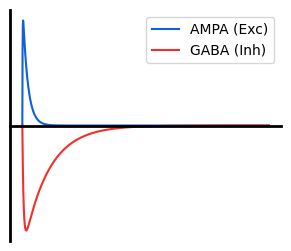

In [12]:
# Plot normalized kernels
plot_kernels(ampa_kernel_norm[0:2000], gaba_kernel_norm[0:2000])

### Kernel Power Spectra

In [13]:
# Compute the power spectra of the kernels
freqs, powers_ampa_kernel = compute_spectrum_fft(ampa_kernel, fs)
freqs, powers_gaba_kernel = compute_spectrum_fft(gaba_kernel, fs)

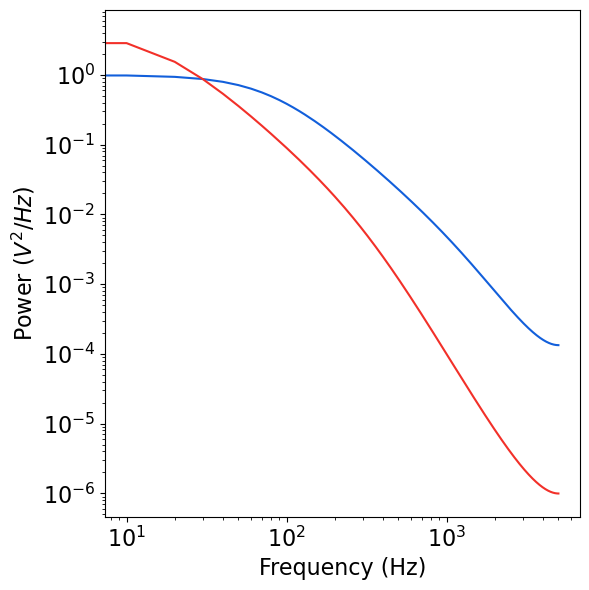

In [14]:
# Plot the power spectra of the kernels
plot_power_spectra(freqs, [powers_ampa_kernel, powers_gaba_kernel],
                   colors=[COLORS['ampa'], COLORS['gaba']])

## PSP Time Series

In [15]:
# Settings for creating spiketrain
rate_ampa = 5
rate_gaba = 5
n_seconds = 2
refractory = len(ampa_kernel)

In [16]:
# Simulate spiketrains
ev_ampa = sim_spiketrain_poisson(rate_ampa, n_seconds * fs, fs, refractory=refractory)
ev_gaba = sim_spiketrain_poisson(rate_gaba, n_seconds * fs, fs, refractory=refractory)

In [17]:
# Convolve spiketrains with kernels
ampa_sig = np.convolve(ev_ampa, ampa_kernel)
gaba_sig = np.convolve(ev_gaba, gaba_kernel)

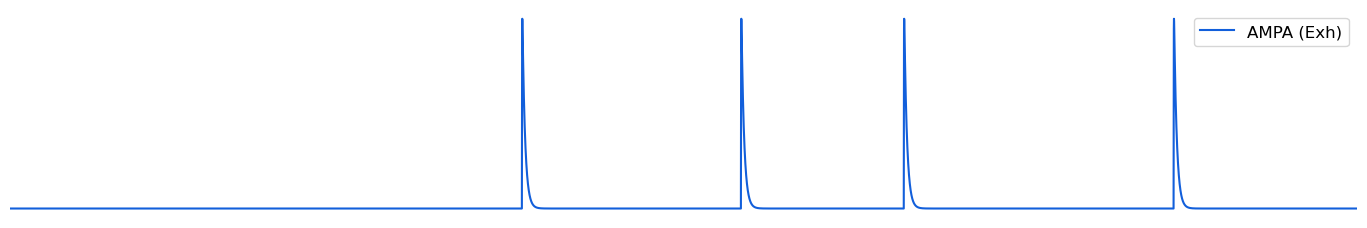

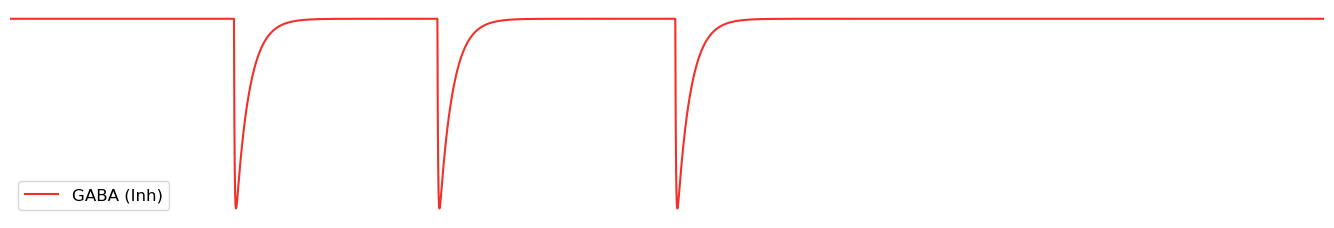

In [18]:
# Plot the convolved time series
plot_time_series(None, ampa_sig, xlim=[0, fs], colors=COLORS['ampa'],
                 labels='AMPA (Exh)', axis=False)
plot_time_series(None, gaba_sig, xlim=[0, fs], colors=COLORS['gaba'],
                 labels='GABA (Inh)', axis=False)

In [19]:
# Make a combined signals (summed across currents)
comb_sig = ampa_sig + gaba_sig

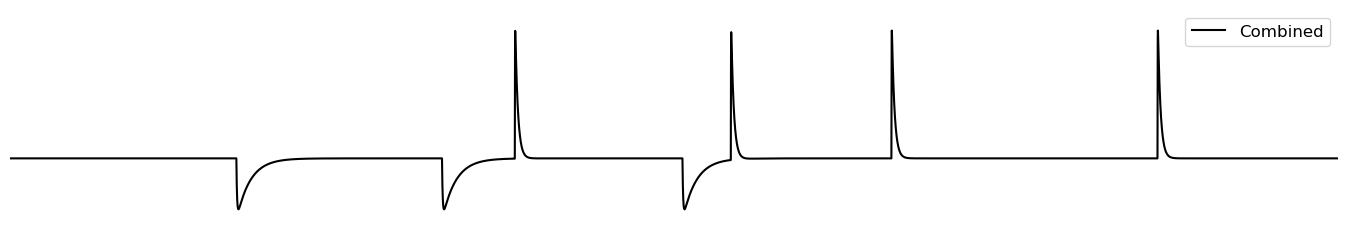

In [20]:
# Plot the combined time series
plot_time_series(None, comb_sig, xlim=[0, fs],
                 labels='Combined', ylim=ts_ylim, axis=False)

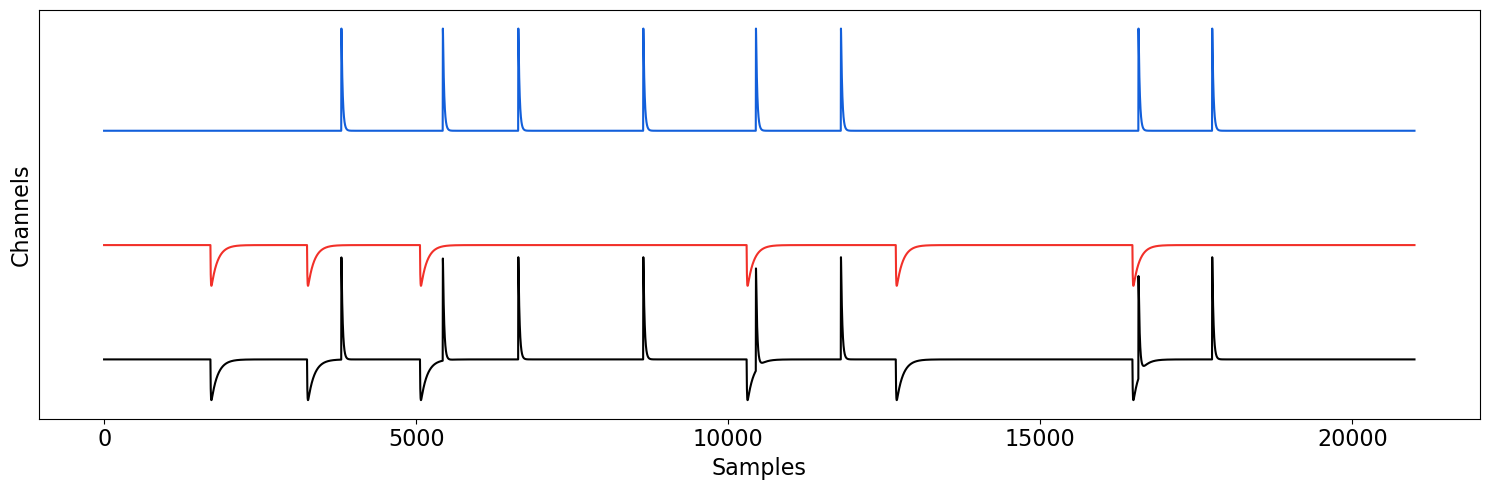

In [21]:
# Plot component & combined time series together
plot_multi_time_series(None, [comb_sig, gaba_sig, ampa_sig],
                       colors=[COLORS['comb'], COLORS['gaba'], COLORS['ampa']])

In [22]:
# Compute power spectrum of the combined signal
freqs_sig, powers_comb = compute_spectrum(comb_sig, fs, nperseg=fs/10)

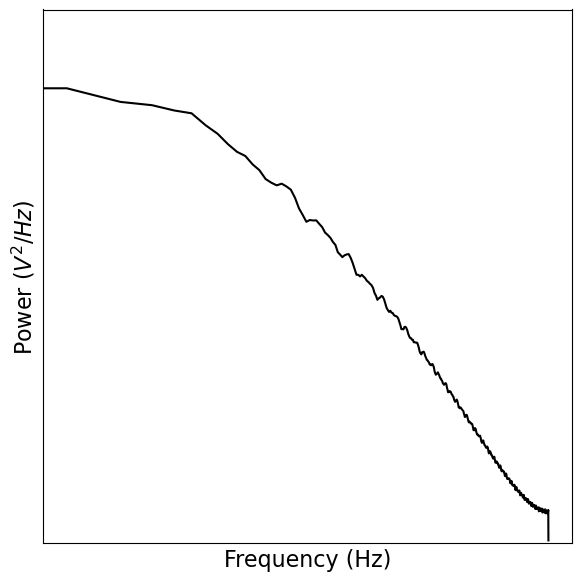

In [23]:
# Visualize the power spectrum of the combined signal
plot_power_spectra(freqs_sig, powers_comb, colors=COLORS['comb'],
                   xticks=[], yticks=[], ylim=psd_ylim)
plt.gca().minorticks_off()

## Set Up Gif-1

In [24]:
ei_img = plt.imread('img/EIsim.png')

def make_axes(add_top_panels=True, add_bottom_panels=True):
    
    fig = plt.figure(figsize=(8, 3), constrained_layout=True)
    gs = fig.add_gridspec(2, 6, hspace=0.15, wspace=0.5)

    axes = {}
    
    # Top Right - GIF text
    axes['tr_text'] = fig.add_subplot(gs[0, 0])
    axes['tr_text'].axis('off')
    if add_top_panels:
        axes['tr_text'].text(0.5, 0.6, 'PSP\nModel', fontsize=18, **TEXT_KWARGS)
    
    axes['tm_schem'] = fig.add_subplot(gs[0, 1:4])
    axes['tm_schem'].axis('off')
    if add_top_panels:
        axes['tm_schem'].imshow(ei_img)

    axes['tl_kern'] = fig.add_subplot(gs[0, 4:])
    if add_top_panels:
        plot_kernels(ampa_kernel_norm[0:2000], gaba_kernel_norm[0:2000], ax=axes['tl_kern'])
    else:
        axes['tl_kern'].axis('off')

    axes['bl_ts'] = fig.add_subplot(gs[1, 0:4])
    axes['bl_ts'].axis('off')
    axes['br_psd'] = fig.add_subplot(gs[1, 4:])
    axes['br_psd'].minorticks_off()
    
    if not add_bottom_panels:
        axes['br_psd'].axis('off')
    
    return fig, axes

## Example Plot

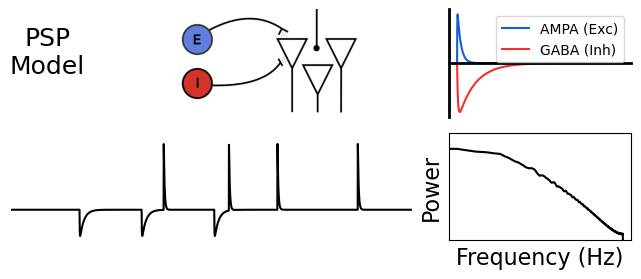

In [25]:
fig, axes = make_axes(add_top_panels=True)
plot_time_series(None, comb_sig,
                 xlim=[0, fs],
                 xticks=[], yticks=[], ylim=ts_ylim, ax=axes['bl_ts'])
plot_power_spectra(freqs_sig, powers_comb, colors=COLORS['comb'], ylim=psd_ylim,
                   xticks=[], yticks=[], ylabel='Power', ax=axes['br_psd'])
plt.gca().minorticks_off()

#fig.savefig('test2.pdf', bbox_inches="tight", dpi=300, transparent=True)

### Gif Data Settings

In [26]:
n_seconds = 1.5

rate1 = 0 
rate2 = 5
rate3 = 10
rate4 = 20

refractory1 = len(ampa_kernel) / 2
refractory2 = int(refractory1 / 2)
refractory3 = int(refractory2 / 2)
refractory4 = int(refractory3 / 2)

In [27]:
events_ampa = np.hstack([
    sim_spiketrain_poisson(rate1, int(1 * fs), fs, refractory=refractory1),
    sim_spiketrain_poisson(rate2, int(n_seconds * fs), fs, refractory=refractory2),
    sim_spiketrain_poisson(rate3, int(n_seconds * fs), fs, refractory=refractory3),
    sim_spiketrain_poisson(rate4, int(n_seconds * fs), fs, refractory=refractory4),
])

events_gaba = np.hstack([
    sim_spiketrain_poisson(rate1, int(1 * fs), fs, refractory=refractory1),
    sim_spiketrain_poisson(rate2, int(n_seconds * fs), fs, refractory=refractory2),
    sim_spiketrain_poisson(rate3, int(n_seconds * fs), fs, refractory=refractory3),
    sim_spiketrain_poisson(rate4, int(n_seconds * fs), fs, refractory=refractory4),
])

In [28]:
ampa_sig = np.convolve(events_ampa, ampa_kernel)
gaba_sig = np.convolve(events_gaba, gaba_kernel)
comb_sig = ampa_sig + gaba_sig

## Builder Function

In [29]:
def build_all(sig, fs, sleep=0.025, save=False):
    
    start_ind = 0
    step_size = 250
    ts_len = fs
    
    n_steps = int(np.floor((len(comb_sig) - ts_len) / 250))
    
    fig, axes = make_axes(add_top_panels=True, add_bottom_panels=False)
    animate_plot(fig, save, 0, 'psp_model', sleep)
    
    ind = incrementer(start=1)
    for tstep in range(n_steps):
        
        clear_output(wait=True)
        
        fig, axes = make_axes(add_top_panels=True if not save else True)
        
        extracted = comb_sig[int(start_ind + tstep * step_size):int(fs + (tstep * step_size))]
        
        plot_time_series(None, extracted,
                         xticks=[], yticks=[], ylim=ts_ylim, ax=axes['bl_ts'])
        
        freqs_sig, powers_comb = compute_spectrum(extracted, fs, nperseg=fs/5)
        plot_power_spectra(freqs_sig, powers_comb, colors=COLORS['comb'], ylim=psd_ylim,
                           xticks=[], yticks=[], ylabel='Power', ax=axes['br_psd'])
        
        animate_plot(fig, save, next(ind), 'psp_model', sleep)

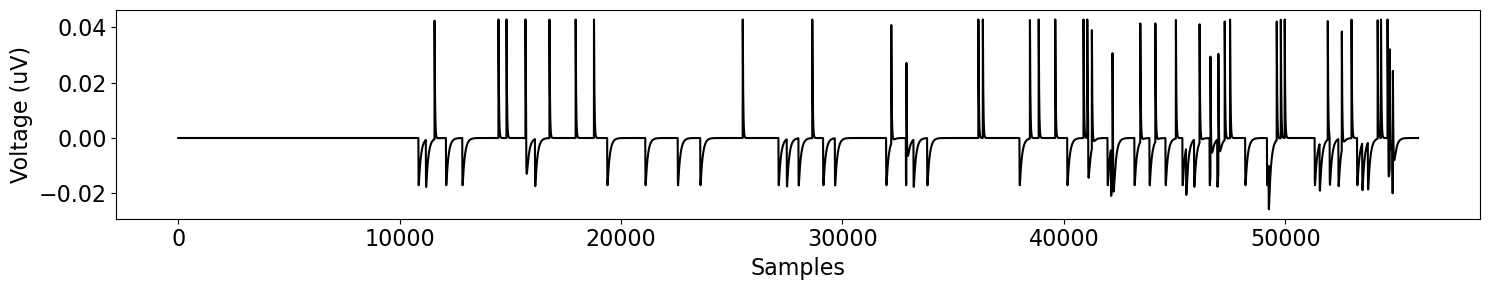

In [30]:
plot_time_series(None, comb_sig)

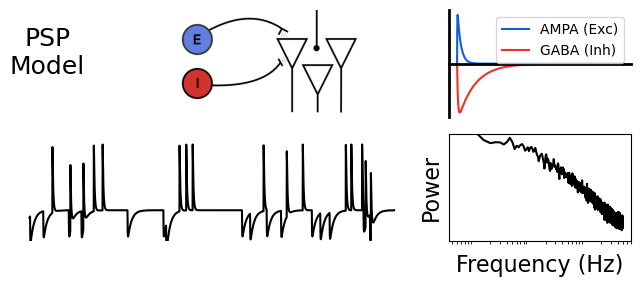

In [31]:
build_all(comb_sig, fs, save=SAVE)

## Synaptic Current

In [32]:
# sim_poisson_pop(1, 100, n_neurons=1, firing_rate=1)

In [33]:
xlim = [500, 15000]

In [34]:
ampa_rate = 1
gaba_rate = 1

In [35]:
ampa_current = sim_synaptic_current(30, fs, tau_r=ampa_rise, tau_d=ampa_decay, firing_rate=ampa_rate)
gaba_current = sim_synaptic_current(30, fs, tau_r=gaba_rise, tau_d=gaba_decay, firing_rate=gaba_rate)

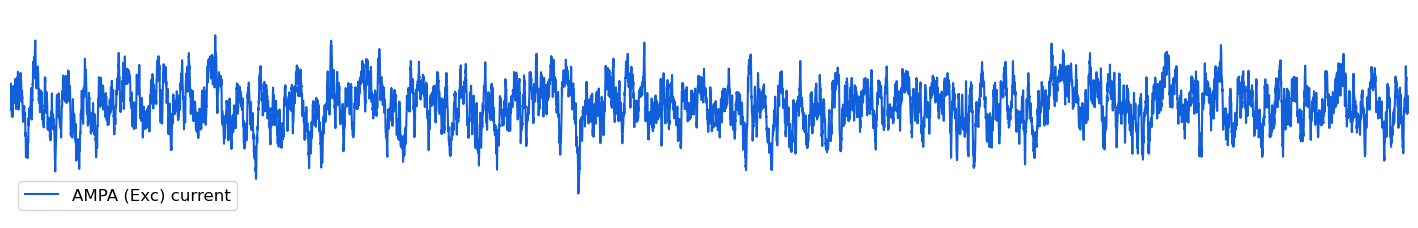

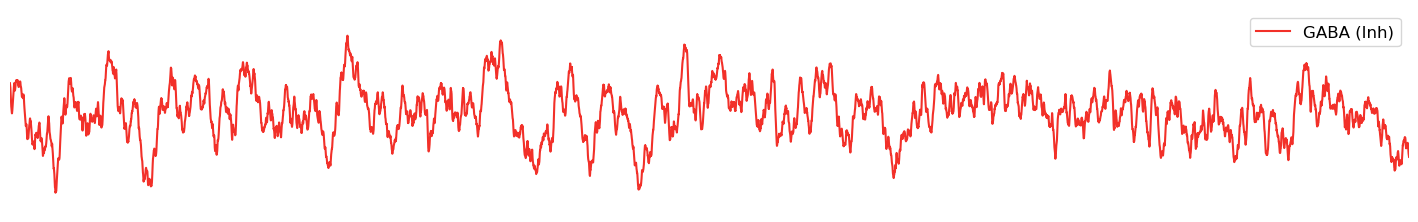

In [36]:
plot_time_series(None, ampa_current, colors=COLORS['ampa'], xlim=xlim, labels='AMPA (Exc) current', axis=False)
plot_time_series(None, gaba_current, colors=COLORS['gaba'], xlim=xlim, labels='GABA (Inh)', axis=False)

In [37]:
ei_ratio = 0.5

In [38]:
combined_sig = (1 - (1/ei_ratio) * ampa_current) + (1/ei_ratio * gaba_current)

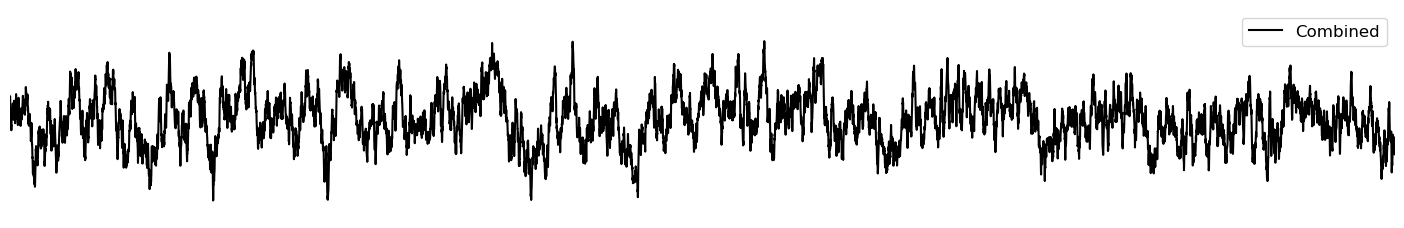

In [39]:
plot_time_series(None, combined_sig, xlim=xlim, labels='Combined', axis=False)

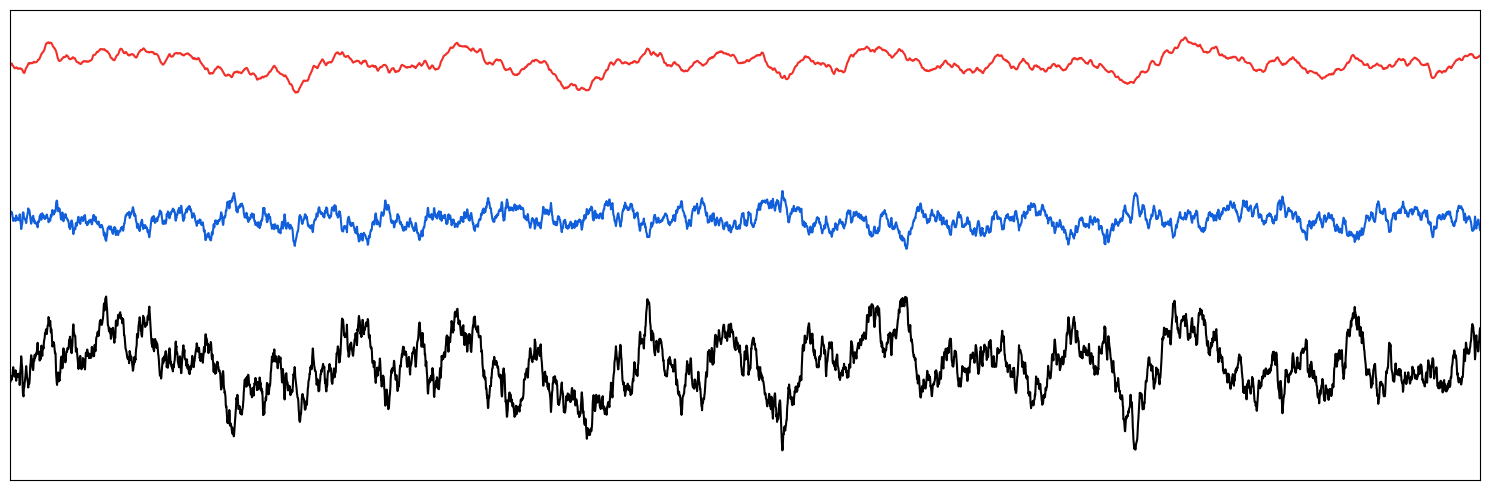

In [40]:
plot_multi_time_series(None, [combined_sig, ampa_current, gaba_current],
                       xlim=[0, 5000], xlabel=None, ylabel=None, xticks=[],
                       colors=[COLORS['comb'], COLORS['ampa'], COLORS['gaba']])

### XX

In [41]:
nperseg = 0.5 * fs

In [42]:
freqs_cur, powers_ampa_cur = compute_spectrum(ampa_current, fs, nperseg=nperseg)
freqs_cur, powers_gaba_cur = compute_spectrum(gaba_current, fs, nperseg=nperseg)
freqs_cur, powers_combined_cur = compute_spectrum(combined_sig, fs, nperseg=nperseg)

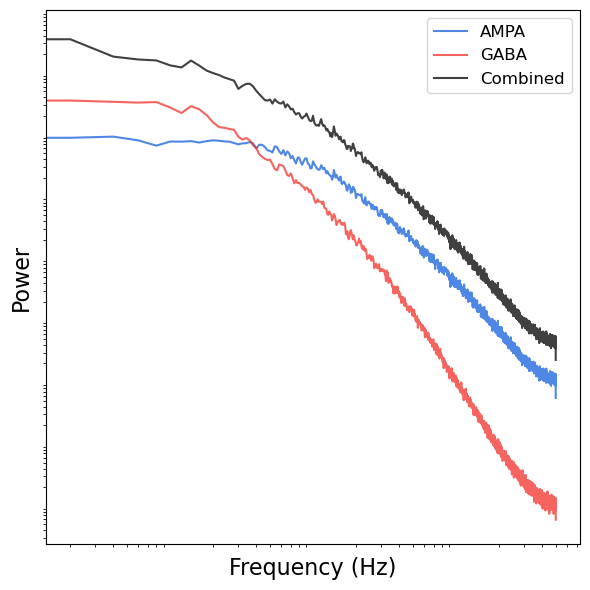

In [43]:
plot_power_spectra(freqs_cur, [powers_ampa_cur, powers_gaba_cur, powers_combined_cur], 
                   xticks=[], yticks=[], ylabel='Power',
                   colors=[COLORS['ampa'], COLORS['gaba'], COLORS['comb']], alpha=0.75, 
                   labels=['AMPA', 'GABA', 'Combined'])
plt.savefig('psp_psd.pdf')

In [44]:
#boost = EI_ratio(i)./((N_I*FR_I*sum(kG))/(N_E*FR_E*sum(kA)));

In [45]:
ei_ratios = [0.5, 1, 2, 4, 8]
combined_sig_psds = []
for ei_ratio in ei_ratios:
    #cur_combined_sig = (1 - (1/ei_ratio) * ampa_current) + (1/ei_ratio * gaba_current)
    cur_combined_sig = ampa_current + (ei_ratio * gaba_current)
    freqs_cur, powers_combined_cur = compute_spectrum(cur_combined_sig, fs, nperseg=5000)
    powers_combined_cur = powers_combined_cur / powers_combined_cur[0]
    combined_sig_psds.append(powers_combined_cur)

In [46]:
np.min(combined_sig_psds[0]), np.max(combined_sig_psds[0])

(np.float64(6.949129445062307e-05), np.float64(2.114201847118785))

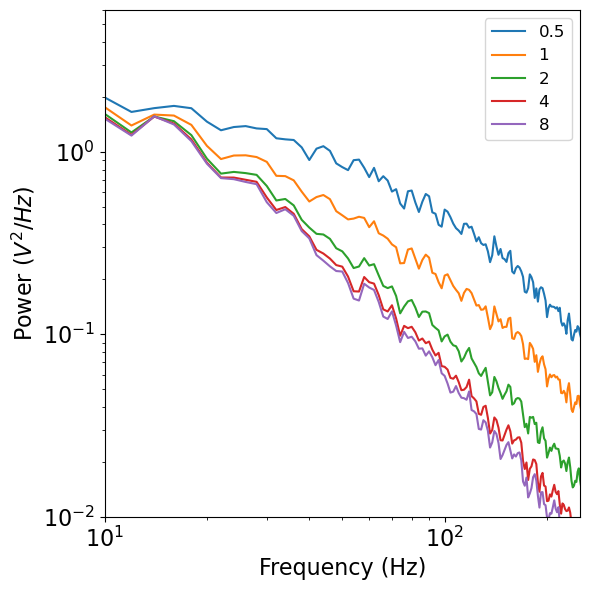

In [47]:
plot_power_spectra(freqs_cur, combined_sig_psds, 
                   #colors=[COLORS['ampa'], COLORS['gaba'], COLORS['comb']], alpha=0.75, 
                   #labels=['AMPA', 'GABA', 'Combined']
                   xlim=[10, 250],
                   ylim=[0.1e-1, 6.0], labels=ei_ratios
                  )

## Set up gif 2

In [48]:
ei_img = plt.imread('img/EIsim.png')

def make_axes2(add_top_panels=True, add_bottom_panels=True):
    
    fig = plt.figure(figsize=(10, 4), constrained_layout=True)
    gs = fig.add_gridspec(3, 6, hspace=0.15, wspace=0.5)

    axes = {}
    
    # Top Right - GIF text
    axes['tr_text'] = fig.add_subplot(gs[0, 0])
    axes['tr_text'].axis('off')
    if add_top_panels:
        axes['tr_text'].text(0.5, 0.6, 'PSP\nModel', fontsize=18, **TEXT_KWARGS)
    
    axes['tm_schem'] = fig.add_subplot(gs[0, 1:4])
    axes['tm_schem'].axis('off')
    if add_top_panels:
        axes['tm_schem'].imshow(ei_img)

#     axes['tl_kern'] = fig.add_subplot(gs[0, 4:])
#     if add_top_panels:
#         plot_kernels(ampa_kernel_norm[0:2000], gaba_kernel_norm[0:2000], ax=axes['tl_kern'])
#     else:
#         axes['tl_kern'].axis('off')

    axes['bl_ts'] = fig.add_subplot(gs[1:, 0:4])
    axes['bl_ts'].axis('off')
    axes['br_psd'] = fig.add_subplot(gs[1:, 4:])
    
    if not add_bottom_panels:
        axes['br_psd'].axis('off')
    
    return fig, axes

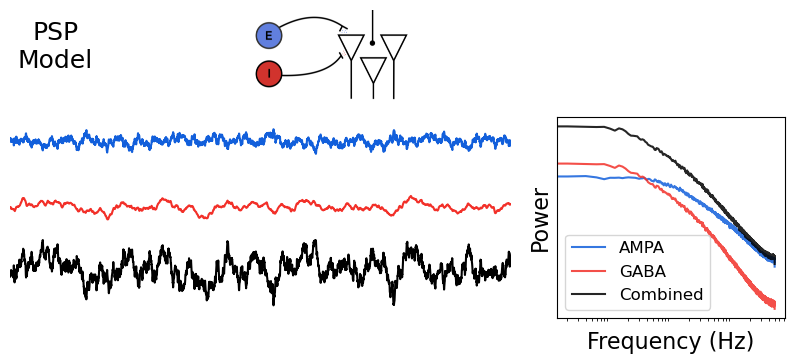

In [49]:
fig, axes = make_axes2()
plot_multi_time_series(None, [combined_sig, gaba_current, ampa_current],
                       xlim=[0, 5000], xlabel=None, ylabel=None, xticks=[],
                       colors=[COLORS['comb'], COLORS['gaba'], COLORS['ampa']], ax=axes['bl_ts'])

plot_power_spectra(freqs_cur, [powers_ampa_cur, powers_gaba_cur, powers_combined_cur], 
                   colors=[COLORS['ampa'], COLORS['gaba'], COLORS['comb']],
                   alpha=0.85, ylabel='Power', xticks=[], yticks=[],
                   labels=['AMPA', 'GABA', 'Combined'], ax=axes['br_psd'])

In [50]:
start = 0
seg_length = 10000
ei_ratios = [1, 2, 4]
combined_sig = np.zeros(len(ei_ratios) * seg_length)
for ind, eir in enumerate(ei_ratios):
    sti = ind * seg_length
    eni = (ind * seg_length) + seg_length
    combined_sig[sti:eni] = ampa_current[start + sti:start + eni] + \
        (eir * gaba_current[start + sti:start + eni])

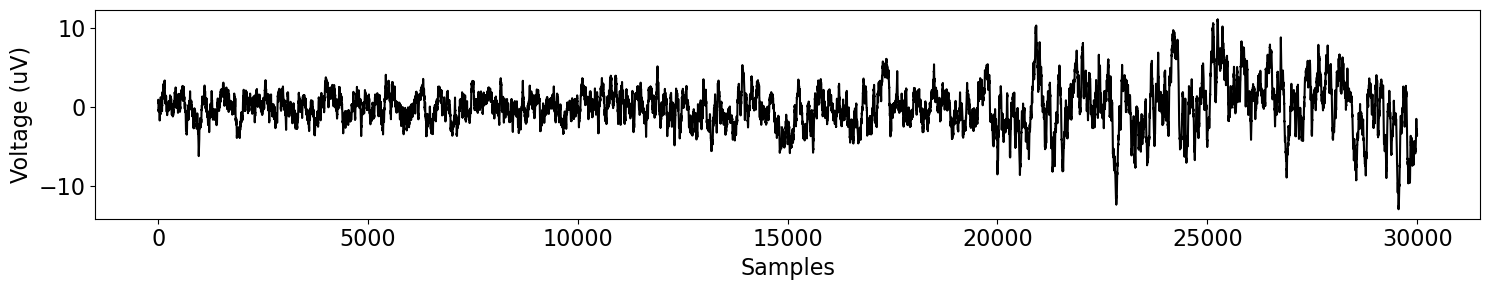

In [51]:
plot_time_series(None, combined_sig)

In [52]:
def build_all(sig, fs, sleep=0.025, save=False):
    
    start_ind = 0
    #step_size = 250
    step_size = 1000
    #ts_len = fs
    ts_len = 5000
    
    n_steps = int(np.floor((len(sig) - ts_len) / step_size))
    
    #fig, axes = make_axes2(add_top_panels=True, add_bottom_panels=False)
    #animate_plot(fig, save, 0, 'psp_current', sleep)
    
    ind = incrementer(start=1)
    for tstep in range(n_steps):
        
        clear_output(wait=True)
        
        fig, axes = make_axes(add_top_panels=True if not save else True)
        
        sti = int(start_ind + tstep * step_size)
        eni = int(start_ind + ts_len + (tstep * step_size))
        #print(sti, eni)
        ext_ampa = ampa_current[sti:eni]
        ext_gaba = gaba_current[sti:eni]
        ext_comb = combined_sig[sti:eni]
        
        plot_multi_time_series(None, [ext_comb, ext_gaba, ext_ampa],
                               #xlim=[0, 5000], 
                               xlabel=None, ylabel=None, xticks=[],
                               colors=[COLORS['comb'], COLORS['gaba'], COLORS['ampa']],
                               ax=axes['bl_ts'])
        
        cfreqs, powers_ampa = compute_spectrum(ext_ampa, fs, nperseg=fs/10)
        cfreqs, powers_gaba = compute_spectrum(ext_gaba, fs, nperseg=fs/10)
        cfreqs, powers_comb = compute_spectrum(ext_comb, fs, nperseg=fs/10)

        plot_power_spectra(cfreqs, [powers_ampa, powers_gaba, powers_comb], 
                           colors=[COLORS['ampa'], COLORS['gaba'], COLORS['comb']],
                           alpha=[0.5, 0.5, 0.85], ylabel='Power', xticks=[], yticks=[],
                           #labels=['AMPA', 'GABA', 'Combined'], 
                           ylim=[0.1e-8, 2.0],
                           ax=axes['br_psd'])
        axes['br_psd'].minorticks_off()

#         plot_power_spectra(freqs_sig, powers_comb, colors=COLORS['comb'], ylim=psd_ylim,
#                            xticks=[], yticks=[], ylabel='Power', ax=axes['br_psd'])
        
        animate_plot(fig, save, next(ind), 'psp_model', sleep)

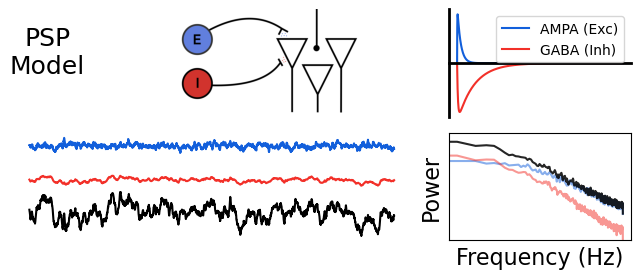

In [53]:
build_all(combined_sig, fs)